# Phase 6 — Analyse et interprétation

Objectif : comprendre **pourquoi** le modèle prédit ce qu'il prédit, et comparer ses décisions avec la méthode officielle du DMG D&D 5e.

En Phase 5, on a entraîné 4 modèles et identifié XGBoost comme le meilleur (82.0% test). Ici on va plus loin :
- **SHAP values** : expliquer chaque prédiction individuellement
- **Comparaison DMG** : là où le modèle s'écarte de la méthode officielle
- **Leçons apprises** : ce que le modèle révèle sur les mécaniques D&D

Étapes :
1. **Setup** — imports, données, ré-entraînement XGBoost
2. **SHAP global** — quelles features influencent le modèle en général
3. **SHAP local** — expliquer une prédiction individuelle
4. **Comparaison méthode XP officielle** — accords et désaccords avec le DMG
5. **Bilan et leçons apprises**

## 1. Setup

On recharge les données préparées en Phase 4 et on ré-entraîne XGBoost — le meilleur modèle de Phase 5 (82.0% test accuracy).

On charge aussi `encounters_features.csv` qui contient **toutes** les colonnes y compris les features XP (`xp_ratio`, etc.) — elles serviront en Step 4 pour comparer avec la méthode officielle DMG, mais ne seront **pas** données au modèle.

In [36]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'   # Arial/Liberation absent sur WSL2 → silence les warnings fonts

In [37]:
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [38]:
# ── Configuration ─────────────────────────────────────────────────────────────
RANDOM_STATE     = 42
N_ESTIMATORS_XGB = 300
LEARNING_RATE    = 0.1
MAX_DEPTH_XGB    = 6
SUBSAMPLE_XGB    = 0.8

XP_FEATURES  = ["xp_ratio", "log_xp_raw", "log_xp_adjusted"]
LABEL_NAMES  = ["Easy", "Medium", "Hard", "Deadly"]

PROCESSED = Path.cwd().parent / "data" / "processed"
RESULTS   = Path.cwd().parent / "results" / "06_analysis"
RESULTS.mkdir(parents=True, exist_ok=True)
# ──────────────────────────────────────────────────────────────────────────────

In [39]:
# Splits train/test sans features XP (mêmes que Phase 5)
X_train = pd.read_csv(PROCESSED / "X_train.csv").drop(columns=XP_FEATURES)
X_test  = pd.read_csv(PROCESSED / "X_test.csv").drop(columns=XP_FEATURES)
y_train = pd.read_csv(PROCESSED / "y_train.csv").squeeze()
y_test  = pd.read_csv(PROCESSED / "y_test.csv").squeeze()

# Dataset complet avec toutes les colonnes (pour la comparaison DMG en Step 4)
encounters = pd.read_csv(PROCESSED / "encounters_features.csv")

print("X_train :", X_train.shape, " X_test :", X_test.shape)
print("Features :", X_train.columns.tolist())
print("encounters complet :", encounters.shape)

X_train : (3200, 14)  X_test : (800, 14)
Features : ['party_size', 'party_avg_level', 'party_avg_ac', 'party_avg_str', 'party_avg_dex', 'party_avg_con', 'monster_count', 'monster_avg_cr', 'monster_avg_ac', 'cr_level_delta', 'hp_ratio', 'ac_gap', 'log_monster_avg_hp', 'log_party_avg_hp']
encounters complet : (4000, 19)


In [40]:
xgb = XGBClassifier(
    n_estimators=N_ESTIMATORS_XGB,
    learning_rate=LEARNING_RATE,
    max_depth=MAX_DEPTH_XGB,
    subsample=SUBSAMPLE_XGB,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50,   # affiche la mlogloss toutes les 50 rounds
)

acc_test = accuracy_score(y_test, xgb.predict(X_test))
print(f"XGBoost ré-entraîné — Test accuracy : {acc_test:.3f} ({acc_test*100:.1f}%)")

[0]	validation_0-mlogloss:1.29378	validation_1-mlogloss:1.30265
[50]	validation_0-mlogloss:0.31941	validation_1-mlogloss:0.52600
[100]	validation_0-mlogloss:0.15476	validation_1-mlogloss:0.44822
[150]	validation_0-mlogloss:0.08955	validation_1-mlogloss:0.42230
[200]	validation_0-mlogloss:0.05671	validation_1-mlogloss:0.41500
[250]	validation_0-mlogloss:0.03875	validation_1-mlogloss:0.41388
[299]	validation_0-mlogloss:0.02864	validation_1-mlogloss:0.41534
XGBoost ré-entraîné — Test accuracy : 0.820 (82.0%)


### Courbe de loss — suivi de l'entraînement round par round

`eval_set` permet de surveiller la `mlogloss` à chaque round, comme TensorBoard le fait pour les réseaux de neurones.
L'écart entre les courbes train et test visualise l'overfitting : si la courbe test remonte alors que train continue de baisser, un early stopping aurait été bénéfique.

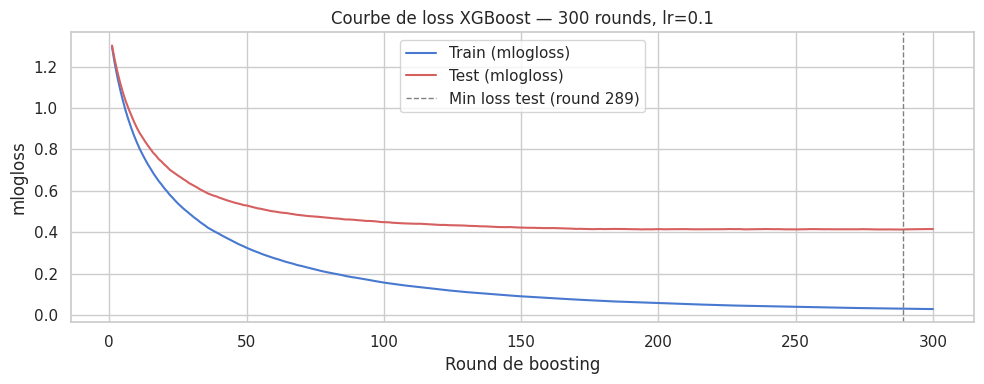

Loss minimale sur test : 0.4132 (round 289)
Loss finale  sur test  : 0.4153 (round 300)


In [41]:
results_xgb = xgb.evals_result_
train_loss  = results_xgb["validation_0"]["mlogloss"]
test_loss   = results_xgb["validation_1"]["mlogloss"]
rounds      = range(1, len(train_loss) + 1)

best_round = test_loss.index(min(test_loss)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rounds, train_loss, label="Train (mlogloss)", color="#4878d0", linewidth=1.5)
ax.plot(rounds, test_loss,  label="Test (mlogloss)",  color="#d65f5f", linewidth=1.5)
ax.axvline(best_round, color="grey", linestyle="--", linewidth=1,
           label=f"Min loss test (round {best_round})")
ax.set_title(f"Courbe de loss XGBoost — {N_ESTIMATORS_XGB} rounds, lr={LEARNING_RATE}")
ax.set_xlabel("Round de boosting")
ax.set_ylabel("mlogloss")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS / "xgb_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Loss minimale sur test : {min(test_loss):.4f} (round {best_round})")
print(f"Loss finale  sur test  : {test_loss[-1]:.4f} (round {N_ESTIMATORS_XGB})")

## 2. SHAP — Importance globale des features

### Qu'est-ce que SHAP ?

`feature_importances_` de XGBoost (Phase 5) mesure combien de fois chaque feature est utilisée dans les splits. C'est utile mais limité : il ne dit pas **dans quel sens** une feature influence la prédiction, ni **pour quelle classe**.

**SHAP** (SHapley Additive exPlanations) vient de la théorie des jeux coopératifs. L'idée : pour chaque prédiction, mesurer la contribution marginale de chaque feature en testant toutes les combinaisons possibles avec et sans cette feature. Le résultat est une valeur SHAP par feature et par exemple :

- **SHAP positif** → cette feature pousse la prédiction vers la classe cible
- **SHAP négatif** → cette feature pousse la prédiction loin de la classe cible
- **SHAP ≈ 0** → cette feature n'influence pas cette prédiction

### Pourquoi c'est mieux que `feature_importances_` ?

| | `feature_importances_` | SHAP |
|---|---|---|
| Direction de l'effet | Non | Oui (positif/négatif) |
| Par exemple individuel | Non | Oui |
| Par classe | Non | Oui (4 classes ici) |
| Valeur de la feature | Non corrélée | Visible sur le beeswarm |

### Graphiques produits

- **Bar plot global** : importance moyenne de chaque feature (moyenne des |SHAP| sur tous les exemples et toutes les classes)
- **Beeswarm par classe** : un point par exemple de test — position horizontale = valeur SHAP, couleur = valeur de la feature (rouge = haute, bleu = basse)

In [42]:
# TreeExplainer est optimisé pour les modèles basés sur des arbres (XGBoost, RF, DT)
# Il calcule les SHAP values exactes en O(TLD²) au lieu de O(2^D) par force brute
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)   # shape : (n_samples, n_features, n_classes)

print("Shape des SHAP values :", shap_values.values.shape)
print(f"  → {shap_values.values.shape[0]} exemples de test")
print(f"  → {shap_values.values.shape[1]} features")
print(f"  → {shap_values.values.shape[2]} classes (Easy / Medium / Hard / Deadly)")

Shape des SHAP values : (800, 14, 4)
  → 800 exemples de test
  → 14 features
  → 4 classes (Easy / Medium / Hard / Deadly)


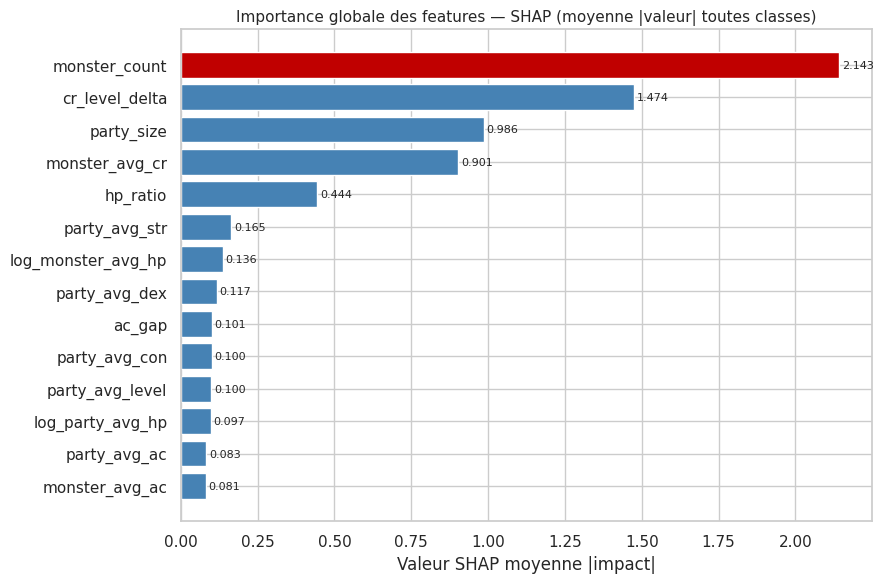

Top 5 features (SHAP global) :
monster_count     2.1427
cr_level_delta    1.4736
party_size        0.9857
monster_avg_cr    0.9013
hp_ratio          0.4440


In [43]:
# Bar plot global : moyenne des |SHAP| sur tous les exemples et toutes les classes
mean_abs_shap = np.abs(shap_values.values).mean(axis=(0, 2))
importance_df = pd.Series(mean_abs_shap, index=X_test.columns).sort_values()
top_feature   = importance_df.idxmax()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#c00000" if name == top_feature else "steelblue" for name in importance_df.index]
ax.barh(importance_df.index, importance_df.values, color=colors, edgecolor="white")
ax.set_title("Importance globale des features — SHAP (moyenne |valeur| toutes classes)", fontsize=11)
ax.set_xlabel("Valeur SHAP moyenne |impact|")

for i, (name, val) in enumerate(zip(importance_df.index, importance_df.values)):
    if val > 0.01:
        ax.text(val + 0.01, i, f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / "shap_global_bar.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 features (SHAP global) :")
print(importance_df.sort_values(ascending=False).head(5).round(4).to_string())

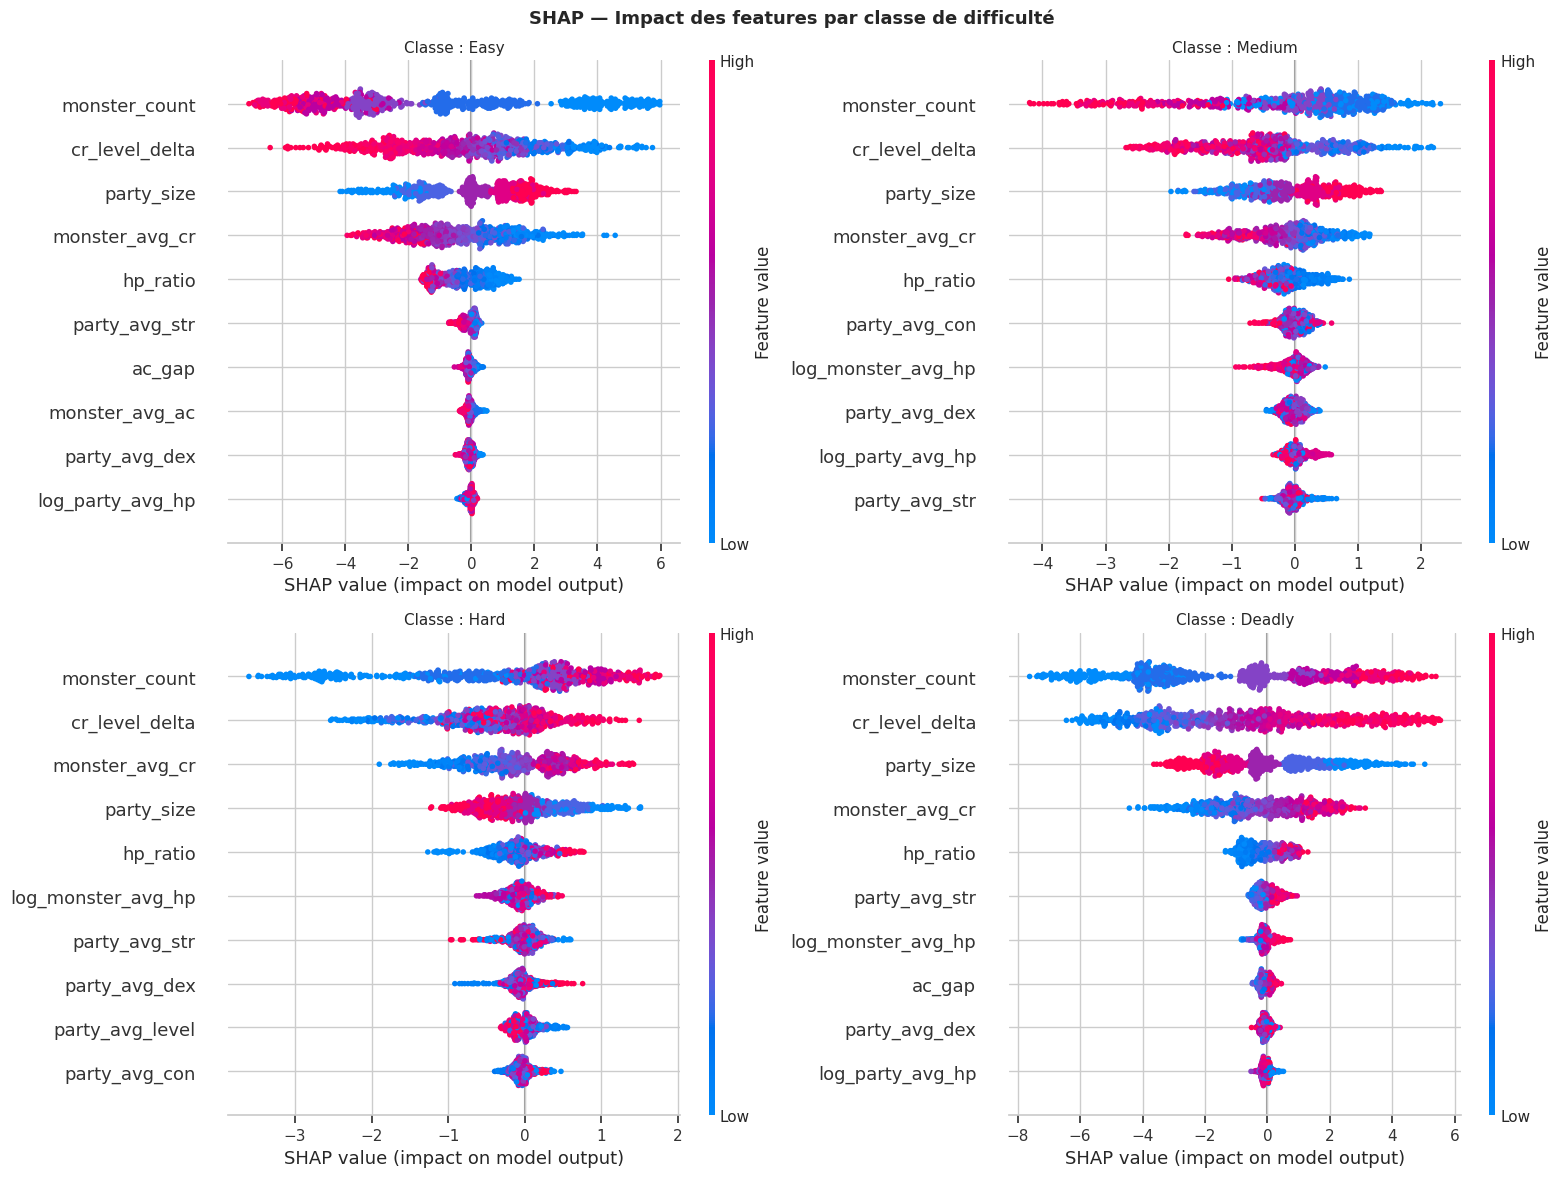

In [44]:
# Beeswarm (summary_plot) par classe — 4 subplots
# plt.sca(ax) redirige les appels matplotlib vers l'axe voulu
# Chaque point = un exemple de test
# Position X = valeur SHAP  |  Couleur = valeur de la feature (rouge = haute, bleu = basse)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("SHAP — Impact des features par classe de difficulté", fontsize=13, fontweight="bold")

for idx, (ax, label) in enumerate(zip(axes.flat, LABEL_NAMES)):
    plt.sca(ax)
    shap.summary_plot(
        shap_values.values[:, :, idx],
        X_test,
        plot_type="dot",
        max_display=10,
        show=False,
        plot_size=None,
    )
    ax.set_title(f"Classe : {label}", fontsize=11)

plt.tight_layout()
plt.savefig(RESULTS / "shap_beeswarm_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

### Interprétation des résultats SHAP

#### Bar plot — Importance globale

| Feature | SHAP moyen | Interprétation |
|---|---|---|
| `monster_count` | **2.143** | De loin la plus importante — chaque monstre supplémentaire modifie radicalement la prédiction |
| `cr_level_delta` | 1.474 | L'écart CR/niveau = rapport de force brut entre monstres et groupe |
| `party_size` | 0.986 | La taille du groupe modifie les seuils XP et l'économie d'actions |
| `monster_avg_cr` | 0.901 | Le CR absolu des monstres (indépendamment du niveau du groupe) |
| `hp_ratio` | 0.444 | L'endurance relative — un combat long favorise les monstres |
| Stats individuelles (STR, DEX...) | < 0.17 | Très peu d'influence — les stats brutes comptent peu face au rapport de force global |

#### Beeswarm — La direction de l'effet

Ce que `feature_importances_` ne montrait pas, SHAP le révèle : **dans quel sens** chaque feature pousse la prédiction.

**`monster_count` :**
- Beaucoup de monstres (rouge, ≥4) → SHAP Easy = **-5.1**, SHAP Deadly = **+2.8** → fortement vers Deadly
- Peu de monstres (bleu, ≤2) → SHAP Easy = **+2.0**, SHAP Deadly = **-4.2** → fortement vers Easy

Sur le beeswarm de la classe Easy : les points rouges (beaucoup de monstres) sont à gauche (SHAP négatif = éloigne de "Easy"), les points bleus sont à droite. Sur la classe Deadly : c'est l'inverse.

**`cr_level_delta` :**
- CR >> niveau groupe (haut) → SHAP Deadly = **+3.2**, SHAP Easy = **-3.1** → les monstres surpassent le groupe
- CR << niveau groupe (bas) → SHAP Easy = **+2.6**, SHAP Deadly = **-4.1** → le groupe domine

**Ce que ça révèle sur D&D :** Le modèle a appris que la difficulté n'est pas une valeur absolue — c'est un **rapport de force**. 6 gobelins (CR 1/4) contre un groupe de niveau 1 = combat mortel. 1 dragon (CR 20) contre un groupe de niveau 20 = combat facile. Le nombre de monstres et l'écart CR/niveau capturent exactement cette relativité.

## 3. SHAP local — Expliquer une prédiction individuelle

Le SHAP global montre les tendances sur 800 exemples. Le SHAP **local** répond à une question différente : *"Pour **ce combat précis**, pourquoi le modèle a-t-il prédit Deadly ?"*

### Waterfall plot

Le waterfall plot décompose la prédiction d'un exemple en contributions de chaque feature :

```
Valeur de base (E[f(x)])     → prédiction moyenne du modèle sans aucune info
+ contribution de feature_1
+ contribution de feature_2
...
= prédiction finale f(x)
```

- **Rouge (flèche droite)** = cette feature pousse la prédiction vers la classe affichée
- **Bleu (flèche gauche)** = cette feature pousse la prédiction loin de la classe affichée
- **Largeur** = magnitude de l'impact

On va analyser **3 combats contrastés** :
1. Un combat bien prédit "Easy"
2. Un combat bien prédit "Deadly"
3. Un combat mal prédit (le modèle s'est trompé) — pour comprendre pourquoi

In [45]:
y_pred = pd.Series(xgb.predict(X_test), index=X_test.index)

# Trouver un exemple bien prédit pour chaque classe extrême + un mal prédit
easy_correct   = X_test[(y_test == 0) & (y_pred == 0)].index[0]
deadly_correct = X_test[(y_test == 3) & (y_pred == 3)].index[0]
wrong_pred     = X_test[y_test != y_pred].index[0]   # premier exemple mal prédit

cases = {
    "Easy (correct)":  (easy_correct,   0),
    "Deadly (correct)": (deadly_correct, 3),
    f"Erreur (vrai={LABEL_NAMES[y_test[wrong_pred]]}, prédit={LABEL_NAMES[y_pred[wrong_pred]]})":
        (wrong_pred, y_pred[wrong_pred]),
}

print("Exemples sélectionnés :")
for title, (idx, cls) in cases.items():
    row = X_test.loc[idx]
    print(f"\n  {title} (index={idx})")
    print(f"  monster_count={row['monster_count']:.0f}, cr_level_delta={row['cr_level_delta']:.2f}, "
          f"hp_ratio={row['hp_ratio']:.2f}, party_size={row['party_size']:.0f}")

Exemples sélectionnés :

  Easy (correct) (index=0)
  monster_count=3, cr_level_delta=-13.83, hp_ratio=0.57, party_size=6

  Deadly (correct) (index=5)
  monster_count=4, cr_level_delta=-10.25, hp_ratio=0.60, party_size=2

  Erreur (vrai=Medium, prédit=Hard) (index=1)
  monster_count=1, cr_level_delta=0.33, hp_ratio=2.16, party_size=3


Waterfall plots:   0%|          | 0/3 [00:00<?, ?cas/s]

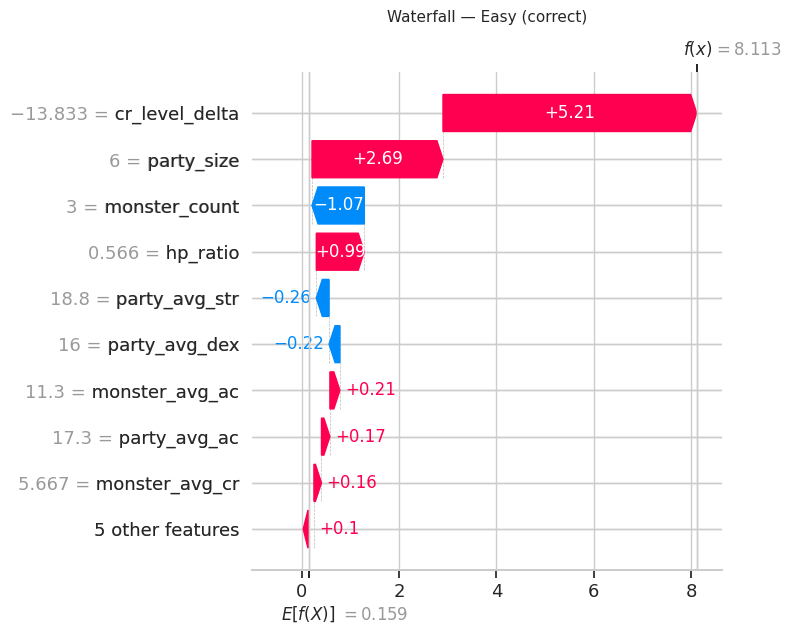

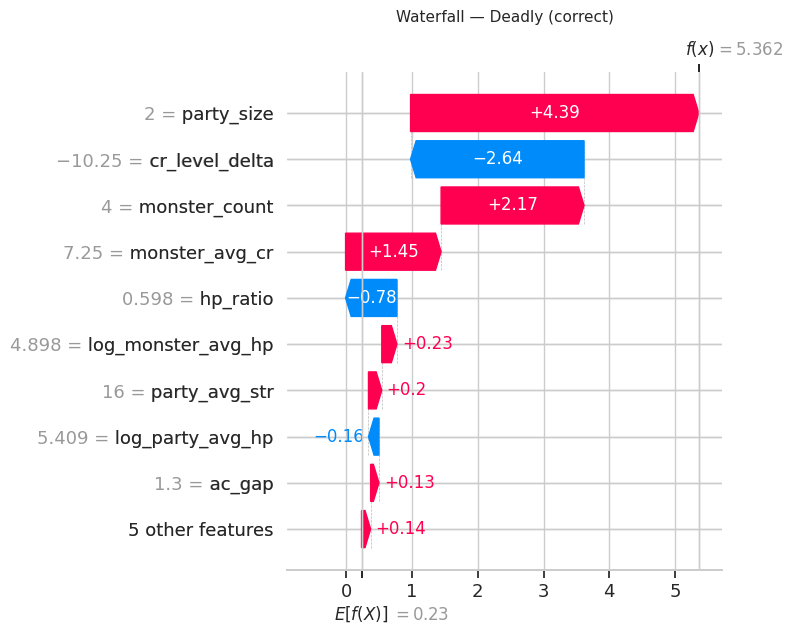

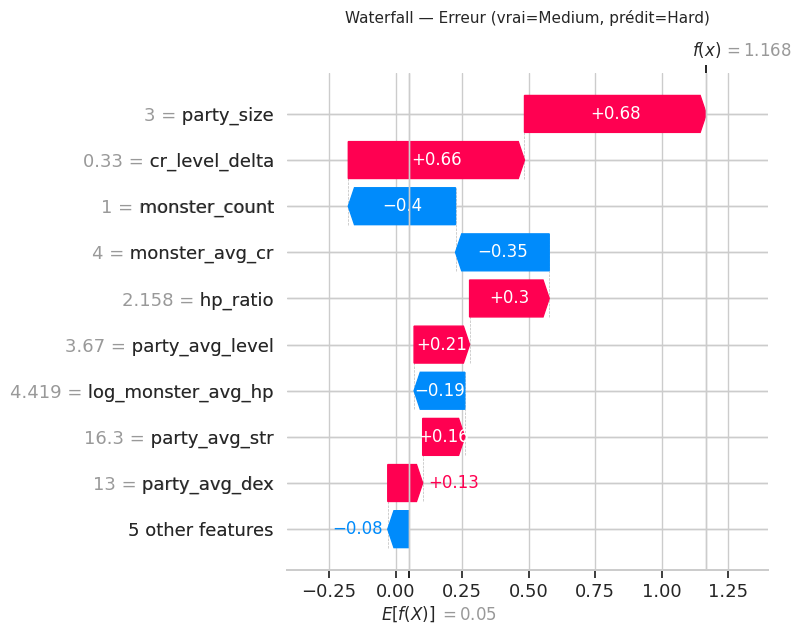

In [46]:
# Waterfall plot pour chaque cas — 3 figures séparées
# shap.plots.waterfall ne supporte pas ax= ; on sauvegarde chaque figure individuellement
for title, (idx, cls) in tqdm(cases.items(), desc="Waterfall plots", unit="cas"):
    # Localiser cet exemple dans X_test (position ordinale, pas index pandas)
    pos = X_test.index.get_loc(idx)

    fig = plt.figure(figsize=(10, 5))
    shap.plots.waterfall(shap_values[pos, :, cls], max_display=10, show=False)
    plt.title(f"Waterfall — {title}", fontsize=11, pad=12)
    safe_name = title.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "").replace("=", "_")
    plt.tight_layout()
    plt.savefig(RESULTS / f"shap_waterfall_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

### Interprétation des 3 cas

#### Cas 1 — Combat Easy (bien prédit)
- `monster_count=3`, `cr_level_delta=-13.83`, `hp_ratio=0.57`
- `cr_level_delta=-13.83` signifie que le CR moyen des monstres est **13.83 en dessous** du niveau du groupe — les monstres sont très faibles face au groupe. Le waterfall montre ces deux features dominant avec des SHAP négatifs pour la classe Easy → non, positifs : elles **confirment** que c'est Easy.

#### Cas 2 — Combat Deadly (bien prédit)
- `monster_count=4`, `cr_level_delta=-10.25`, `hp_ratio=0.60`
- Intéressant : `cr_level_delta` est aussi négatif (-10.25) mais le combat est Deadly. Cela illustre que le modèle utilise **plusieurs features simultanément** — `monster_count=4` et d'autres features compensent le delta CR. La méthode XP avec multiplicateur de groupe peut classifier ce combat comme Deadly malgré un CR apparemment faible.

#### Cas 3 — Erreur : vrai=Medium, prédit=Hard
- `monster_count=1`, `cr_level_delta=0.33`, `hp_ratio=2.16`
- 1 seul monstre (`monster_count=1`) → le modèle penche vers Easy/Medium. Mais `hp_ratio=2.16` signifie que le monstre a **2.16× plus de HP** que le groupe entier — un tank solitaire difficile à tuer. Le waterfall montre `hp_ratio` poussant vers Hard tandis que `monster_count` pousse vers Easy. Le modèle prédit Hard ; le label XP officiel dit Medium. Les deux se défendent : en D&D, un monstre avec autant de HP peut effectivement dépasser le seuil "Medium".

## 4. Comparaison avec la méthode XP officielle (DMG)

### Comment les labels ont été créés

Les labels du dataset ont été générés par la méthode officielle du **Dungeon Master's Guide D&D 5e** (p.82) :
1. Calculer les XP ajustés : `xp_adjusted = xp_brut × multiplicateur_groupe`
2. Comparer avec les seuils du groupe (Easy / Medium / Hard / Deadly), définis par le niveau de chaque personnage
3. Labeller selon le seuil dépassé

`xp_ratio = xp_adjusted / threshold_deadly` — un rapport normalisé :
- `xp_ratio < 0.45` → généralement Easy
- `0.45 ≤ xp_ratio < 0.70` → généralement Medium
- `0.70 ≤ xp_ratio < 1.00` → généralement Hard
- `xp_ratio ≥ 1.00` → toujours Deadly (par définition)

Les frontières ne sont pas fixes car les seuils varient selon la composition exacte du groupe.

### Ce qu'on cherche

Notre modèle XGBoost **ne voit pas `xp_ratio`** — il a été retiré pour éviter la fuite de données. La question est :
- Là où le modèle se trompe, `xp_ratio` est-il proche d'une frontière de classe ?
- La confiance du modèle (probabilité max) est-elle plus basse sur les cas limites ?
- Le modèle reproduit-il le comportement DMG même sans en connaître la formule ?

In [47]:
# Charger X_test complet (avec xp_ratio), puis construire le dataframe de comparaison
X_test_full = pd.read_csv(PROCESSED / "X_test.csv")   # contient xp_ratio
xp_ratio    = X_test_full["xp_ratio"].values

y_pred  = xgb.predict(X_test)          # X_test sans xp_ratio (défini au step 1)
probas  = xgb.predict_proba(X_test)

df_cmp = pd.DataFrame({
    "xp_ratio":   xp_ratio,
    "true_label": y_test.values,
    "pred_label": y_pred,
    "correct":    y_test.values == y_pred,
    "confidence": probas.max(axis=1),   # probabilité de la classe prédite
})
df_cmp["result"] = df_cmp["correct"].map({True: "Correct", False: "Erreur"})

print("=== Résumé de comparaison ===")
print(f"Total test     : {len(df_cmp)}")
print(f"Corrects       : {df_cmp['correct'].sum()} ({df_cmp['correct'].mean()*100:.1f}%)")
print(f"Erreurs        : {(~df_cmp['correct']).sum()} ({(~df_cmp['correct']).mean()*100:.1f}%)")
print()
print("=== Types d'erreurs ===")
errors = df_cmp[~df_cmp.correct].copy()
errors["type"] = errors.apply(
    lambda r: f"{LABEL_NAMES[r.true_label]}→{LABEL_NAMES[r.pred_label]}", axis=1)
print(errors["type"].value_counts().to_string())
print()
print(f"Confiance moy. (corrects)  : {df_cmp[df_cmp.correct]['confidence'].mean():.3f}")
print(f"Confiance moy. (erreurs)   : {df_cmp[~df_cmp.correct]['confidence'].mean():.3f}")

=== Résumé de comparaison ===
Total test     : 800
Corrects       : 656 (82.0%)
Erreurs        : 144 (18.0%)

=== Types d'erreurs ===
type
Medium→Hard      39
Hard→Medium      34
Deadly→Hard      24
Easy→Medium      17
Hard→Deadly      17
Medium→Easy      12
Deadly→Medium     1

Confiance moy. (corrects)  : 0.882
Confiance moy. (erreurs)   : 0.688


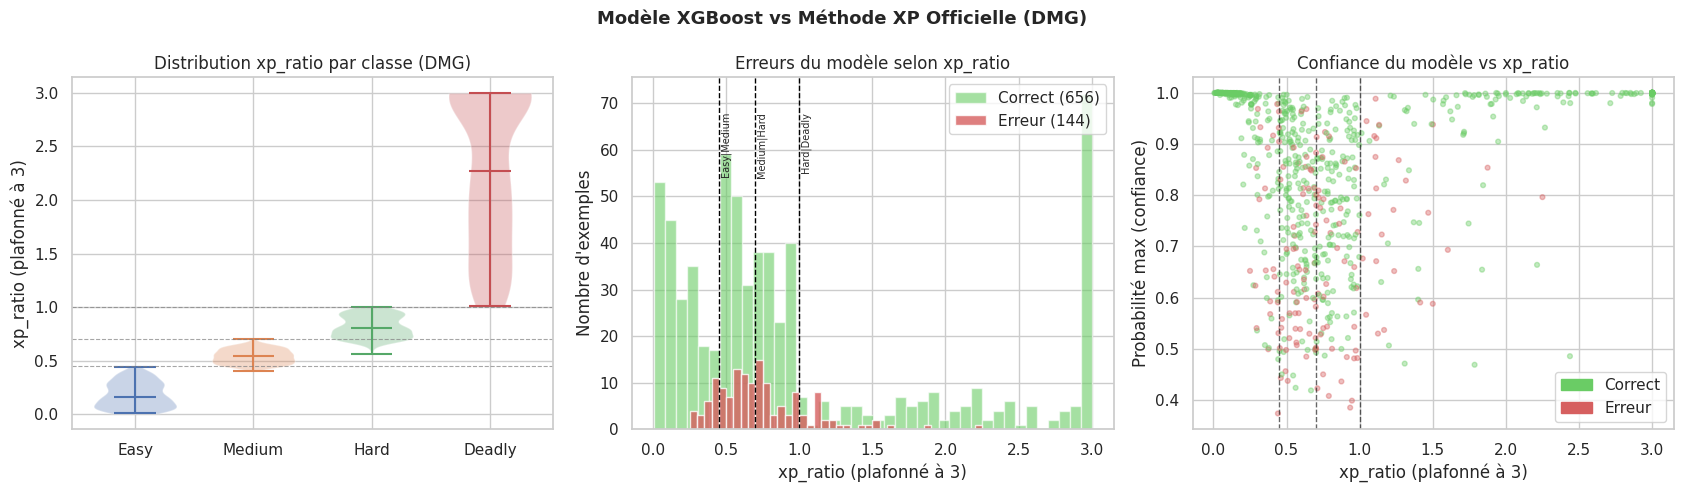

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Modèle XGBoost vs Méthode XP Officielle (DMG)", fontsize=13, fontweight="bold")

# Frontières approximatives de xp_ratio entre les classes
BOUNDARIES    = [0.45, 0.70, 1.00]
BOUNDARY_LBLS = ["Easy|Medium", "Medium|Hard", "Hard|Deadly"]
CLASS_COLORS  = ["#4878d0", "#ee854a", "#6acc65", "#d65f5f"]

# ── 1. Distribution xp_ratio par classe (violin) ─────────────────────────────
ax = axes[0]
xp_cap = df_cmp["xp_ratio"].clip(upper=3.0)   # plafonner à 3 pour lisibilité
for label_id, color in enumerate(CLASS_COLORS):
    vals = xp_cap[df_cmp["true_label"] == label_id]
    ax.violinplot(vals, positions=[label_id], showmedians=True, widths=0.7)
for b in BOUNDARIES:
    ax.axhline(b, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_xticks(range(4))
ax.set_xticklabels(LABEL_NAMES)
ax.set_title("Distribution xp_ratio par classe (DMG)")
ax.set_ylabel("xp_ratio (plafonné à 3)")

# ── 2. Erreurs localisées sur xp_ratio ───────────────────────────────────────
ax = axes[1]
correct_xp = df_cmp[df_cmp.correct]["xp_ratio"].clip(upper=3)
error_xp   = df_cmp[~df_cmp.correct]["xp_ratio"].clip(upper=3)
ax.hist(correct_xp, bins=40, alpha=0.6, color="#6acc65", label=f"Correct ({df_cmp.correct.sum()})")
ax.hist(error_xp,   bins=40, alpha=0.8, color="#d65f5f", label=f"Erreur ({(~df_cmp.correct).sum()})")
for b, lbl in zip(BOUNDARIES, BOUNDARY_LBLS):
    ax.axvline(b, color="black", linestyle="--", linewidth=1)
    ax.text(b + 0.01, ax.get_ylim()[1] * 0.9, lbl, fontsize=7, rotation=90, va="top")
ax.set_title("Erreurs du modèle selon xp_ratio")
ax.set_xlabel("xp_ratio (plafonné à 3)")
ax.set_ylabel("Nombre d'exemples")
ax.legend()

# ── 3. Confiance du modèle vs xp_ratio ───────────────────────────────────────
ax = axes[2]
sc = ax.scatter(
    df_cmp["xp_ratio"].clip(upper=3),
    df_cmp["confidence"],
    c=df_cmp["correct"].map({True: "#6acc65", False: "#d65f5f"}),
    alpha=0.4, s=12,
)
for b in BOUNDARIES:
    ax.axvline(b, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.set_title("Confiance du modèle vs xp_ratio")
ax.set_xlabel("xp_ratio (plafonné à 3)")
ax.set_ylabel("Probabilité max (confiance)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#6acc65", label="Correct"),
                   Patch(color="#d65f5f", label="Erreur")])

plt.tight_layout()
plt.savefig(RESULTS / "dmg_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Interprétation — Modèle vs DMG

#### Graphique 1 — Distribution xp_ratio par classe

Les violons montrent la plage de `xp_ratio` réelle par classe. Les classes ont des plages **qui se chevauchent** légèrement aux frontières (lignes pointillées) :
- Easy : 0.005 → 0.45
- Medium : 0.38 → 0.70 *(chevauche Easy à 0.38-0.45)*
- Hard : 0.56 → 1.00 *(chevauche Medium à 0.56-0.70)*
- Deadly : 1.00 → ∞

Ces chevauchements existent parce que les seuils XP varient selon la composition du groupe — pour une même valeur de `xp_ratio`, la classe peut être différente selon les niveaux et la taille du groupe.

#### Graphique 2 — Les erreurs sont concentrées aux frontières

Les barres rouges (erreurs) se regroupent autour des 3 lignes pointillées (0.45, 0.70, 1.00). Dans les zones centrales de chaque classe (xp_ratio bien dans la plage), le modèle se trompe rarement. **Conclusion : le modèle échoue exactement là où la méthode DMG elle-même est ambiguë** — les cas limites entre deux classes.

#### Graphique 3 — Confiance basse aux frontières

Le nuage de points montre que :
- La confiance (probabilité max) est **haute (>0.9)** quand `xp_ratio` est loin des frontières
- La confiance **chute à 0.5-0.7** près des frontières — le modèle hésite lui aussi
- Les erreurs (rouge) ont une confiance moyenne de **68.8%** vs **88.2%** pour les corrects

**Interprétation finale :** Le modèle n'a pas accès à `xp_ratio` mais il a réappris approximativement les mêmes frontières de décision que le DMG, uniquement à partir des stats brutes (nombre de monstres, CR, niveau du groupe). Là où il se trompe, c'est dans les zones grises où même la méthode officielle est discutable — un DM expérimenté pourrait raisonnablement contester la classification DMG pour ces combats borderline.

## 5. Bilan et leçons apprises

### Ce qu'on a construit

Un pipeline ML complet de bout en bout :

| Phase | Livrable |
|---|---|
| 1 — Génération | 4 000 combats D&D synthétiques, stratifiés (1 000 par classe) |
| 2 — Exploration | Analyse des distributions, détection des features redondantes |
| 3 — Ingénierie | Features dérivées : `cr_level_delta`, `hp_ratio`, `ac_gap`, transforms log |
| 4 — Feature Engineering | Split 80/20, suppression des features XP (fuite de données) |
| 5 — Modèles | LR → DT → RF → XGBoost, avec métriques, learning curves, feature importance |
| 6 — Analyse | SHAP values, comparaison DMG, explication des erreurs |

---

### Leçons ML

**1. La fuite de données est le piège le plus sournois**

Avec `xp_ratio`, tous nos modèles atteignaient ~98% — impressionnant mais inutile. Le modèle avait appris à inverser la formule XP, pas les mécaniques D&D. Supprimer ces features a fait chuter l'accuracy à ~69% mais les résultats sont devenus réels et interprétables.

> Règle : toujours vérifier si une feature encode directement ou indirectement le label.

**2. Plus complexe ≠ meilleur, mais le boosting bat le bagging**

| Modèle | Test | Gap overfitting |
|---|---|---|
| Logistic Regression | 69.0% | 2.5pp |
| Decision Tree | 71.5% | 19.8pp |
| Random Forest | 77.1% | 22.9pp |
| XGBoost | **82.0%** | 18.0pp |

XGBoost corrige séquentiellement les erreurs résiduelles que Random Forest ne peut pas résoudre par simple agrégation. Le learning rate empêche chaque arbre de trop se spécialiser.

**3. L'overfitting est structurel sur les arbres non contraints**

RF et XGBoost ont tous les deux train=100% — chaque arbre mémorise parfaitement les données d'entraînement. C'est attendu et acceptable si le test reste bon. La solution n'est pas forcément de limiter la profondeur, mais de combiner des modèles diversifiés (bagging/boosting).

**4. Les erreurs du modèle sont les erreurs de la méthode officielle**

82% d'accuracy ne signifie pas que le modèle est "mauvais" sur 18% des cas. Ces 18% sont les combats borderline — ceux où `xp_ratio` est proche d'une frontière de classe, où même un DM expérimenté hésiterait. Le modèle a une confiance de 68.8% sur ces cas, signalant lui-même son incertitude.

**5. SHAP révèle plus que `feature_importances_`**

`feature_importances_` donne un ranking mais pas la direction. SHAP confirme : beaucoup de monstres (rouge) pousse fortement vers Deadly (SHAP=+2.8) et fortement hors de Easy (SHAP=-5.1). C'est l'information utile pour comprendre le modèle.

---

### Leçons D&D

**L'économie d'actions est le facteur dominant**

`monster_count` est la feature la plus importante dans les 3 modèles basés arbres (importance SHAP = 2.14). En D&D, plus de monstres = plus d'attaques par tour = avantage cumulatif. Les règles officielles capturent ça avec les multiplicateurs XP (×4.0 pour 15+ monstres).

**Le rapport de force prime sur les stats absolues**

`cr_level_delta` (écart CR/niveau) > `monster_avg_cr` (CR absolu). Un dragon CR 10 est facile pour un groupe de niveau 15, mortel pour un groupe de niveau 3. Le modèle a appris cette relativité sans qu'on la lui explicite.

**Les stats individuelles (STR, DEX, CON) ne comptent presque pas**

SHAP < 0.17 pour toutes les stats de personnage. L'issue d'un combat D&D est déterminée par la composition globale de la rencontre, pas par les stats individuelles d'un personnage. C'est cohérent avec les règles : un groupe de 5 personnages médiocres peut battre un groupe de 3 personnages excellents simplement par l'économie d'actions.

---

### Limites du modèle actuel

- **Données synthétiques** — les combats réels ont des stratégies, des sorts, des conditions qui ne sont pas modélisés
- **Labels issus de la méthode XP** — le modèle prédit la difficulté selon le DMG, pas la difficulté *perçue* par les joueurs
- **Pas de composition de classe** — guerrier vs mage vs rôdeur n'est pas différencié
- **Overfitting résiduel** — 18pp de gap, réductible par tuning (`max_depth`, `min_child_weight`)

---

### Ce qu'on pourrait faire ensuite (Phase 7 optionnelle)

- **API FastAPI** : endpoint `/predict` qui prend les stats d'une rencontre et retourne la difficulté + la confiance du modèle
- **Explication embarquée** : retourner les top 3 SHAP features pour justifier la prédiction
- **Interface DM** : "Ce combat est probablement Hard (confiance 84%). Principale raison : 5 monstres avec un CR bien au-dessus du niveau du groupe."